# Chest X-Ray — Complete Data Preprocessing Pipeline

This notebook consolidates the previous preprocessing workflow into **one reproducible notebook**.

## Strict workflow

```text
OLD / ORIGINAL DATASET
        │
        ├── identify ORIGINAL source
        ▼
IMAGE ACQUISITION
        ▼
CLEANING
        ▼
BALANCING  (TRAIN ONLY)
        ▼
CLAHE ENHANCEMENT
        ▼
LUNG MASK
        ▼
224 × 224
        ▼
FINAL DATASET
```

### Important rules

1. `Lung_Disease_Dataset` is treated as the **only original source**.
2. The original dataset is **never modified**.
3. The existing `train / val / test` split is preserved.
4. No old `ViT`, `Clean`, `Final`, or `Split_V*` datasets are merged.
5. Balancing is applied **only to the training set**.
6. Validation and test are not oversampled.
7. Every stage writes to `Respira/data/`.
8. Manifests and reports make the whole pipeline reproducible.


In [1]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

from pathlib import Path
import os
import json
import shutil
import hashlib
import random
from collections import Counter

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

# Your current project root
PROJECT_ROOT = Path(r"C:\Users\rushi\Desktop\Respira")

# ORIGINAL DATASET — READ ONLY
ORIGINAL_DATASET = PROJECT_ROOT / "Lung_Disease_Dataset"

# ALL GENERATED DATA
DATA_ROOT = PROJECT_ROOT / "data"

# Notebook/script workspace
PREPROCESSING_ROOT = PROJECT_ROOT / "preprocessing"

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

SEED = 42
IMAGE_SIZE = (224, 224)

# CLAHE parameters
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

# Supported image formats
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

# Balancing:
# "max_class" = oversample every train class to the largest class
BALANCE_METHOD = "max_class"

# Output final images as 3-channel RGB PNG.
# This works cleanly with DenseNet121, ViT and EfficientNet-B0.
OUTPUT_CHANNELS = 3

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

DIRS = {
    "acquired": DATA_ROOT / "acquired",
    "cleaned": DATA_ROOT / "cleaned",
    "cleaned_rejected": DATA_ROOT / "cleaned" / "rejected",
    "balanced": DATA_ROOT / "balanced",
    "clahe": DATA_ROOT / "clahe",
    "masked": DATA_ROOT / "masked",
    "processed": DATA_ROOT / "processed",
    "manifests": DATA_ROOT / "manifests",
    "reports": DATA_ROOT / "reports",
}

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Original     :", ORIGINAL_DATASET)
print("Data output  :", DATA_ROOT)


Project root : C:\Users\rushi\Desktop\Respira
Original     : C:\Users\rushi\Desktop\Respira\Lung_Disease_Dataset
Data output  : C:\Users\rushi\Desktop\Respira\data


## 2. Identify and validate the original source

This cell deliberately points to **one dataset only**.

The notebook will stop if the selected folder does not contain the expected `train`, `val`, and `test` directories.

It will also reject paths whose names look like previously processed datasets.


In [2]:
# ============================================================
# 2. IDENTIFY ORIGINAL SOURCE
# ============================================================

FORBIDDEN_SOURCE_WORDS = {
    "vit", "clean", "final", "split",
    "processed", "preprocessed", "balanced"
}

if not ORIGINAL_DATASET.exists():
    raise FileNotFoundError(
        f"Original dataset was not found:\n{ORIGINAL_DATASET}"
    )

folder_name = ORIGINAL_DATASET.name.lower()

if any(word in folder_name for word in FORBIDDEN_SOURCE_WORDS):
    raise RuntimeError(
        f"Safety check failed. This folder looks processed: {ORIGINAL_DATASET}"
    )

required_splits = ["train", "val", "test"]
missing_splits = [
    split for split in required_splits
    if not (ORIGINAL_DATASET / split).is_dir()
]

if missing_splits:
    raise RuntimeError(
        f"Missing required split folders: {missing_splits}\n"
        f"Expected: train/, val/, test/"
    )

print("✓ Original source validated")
print("✓ Existing train/val/test split will be preserved")
print("✓ Original dataset will not be modified")


✓ Original source validated
✓ Existing train/val/test split will be preserved
✓ Original dataset will not be modified


## 3. Inspect the original dataset

The dataset currently appears to use disease/class folders such as:

- Atelectasis
- Bacterial Pneumonia
- Normal
- Pulmonary Edema
- Tuberculosis
- Viral Pneumonia
- `random`

The notebook does **not** silently delete `random`. It reports it as a class so it can be reviewed before training.


ORIGINAL DATASET INSPECTION


,split,class,images,path
0,train,.ipynb_checkpoints,0,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
1,train,Atelectasis,1218,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
2,train,Bacterial Pneumonia,1205,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
3,train,Normal,1207,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
4,train,Pulmonary Edema,350,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
5,train,random,561,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
6,train,Tuberculosis,1220,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
7,train,Viral Pneumonia,1204,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
8,val,.ipynb_checkpoints,0,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
9,val,Atelectasis,406,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...



Total Images: 11,397

IMAGES BY SPLIT


,split,images,percentage
0,test,2156,18.92
1,train,6965,61.11
2,val,2276,19.97



IMAGES BY CLASS


,class,images,percentage
0,Tuberculosis,2034,17.85
1,Atelectasis,2031,17.82
2,Normal,2013,17.66
3,Bacterial Pneumonia,2009,17.63
4,Viral Pneumonia,2008,17.62
5,random,802,7.04
6,Pulmonary Edema,500,4.39
7,.ipynb_checkpoints,0,0.00



CLASS DISTRIBUTION ACROSS SPLITS


split,test,train,val
class,,,
.ipynb_checkpoints,0,0,0
Atelectasis,407,1218,406
Bacterial Pneumonia,403,1205,401
Normal,404,1207,402
Pulmonary Edema,50,350,100
Tuberculosis,408,1220,406
Viral Pneumonia,403,1204,401
random,81,561,160


,split,class,images,path
0,train,.ipynb_checkpoints,0,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
8,val,.ipynb_checkpoints,0,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
16,test,.ipynb_checkpoints,0,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...



CLASS IMBALANCE
Largest class : 2,034
Smallest class: 0
Imbalance ratio: inf


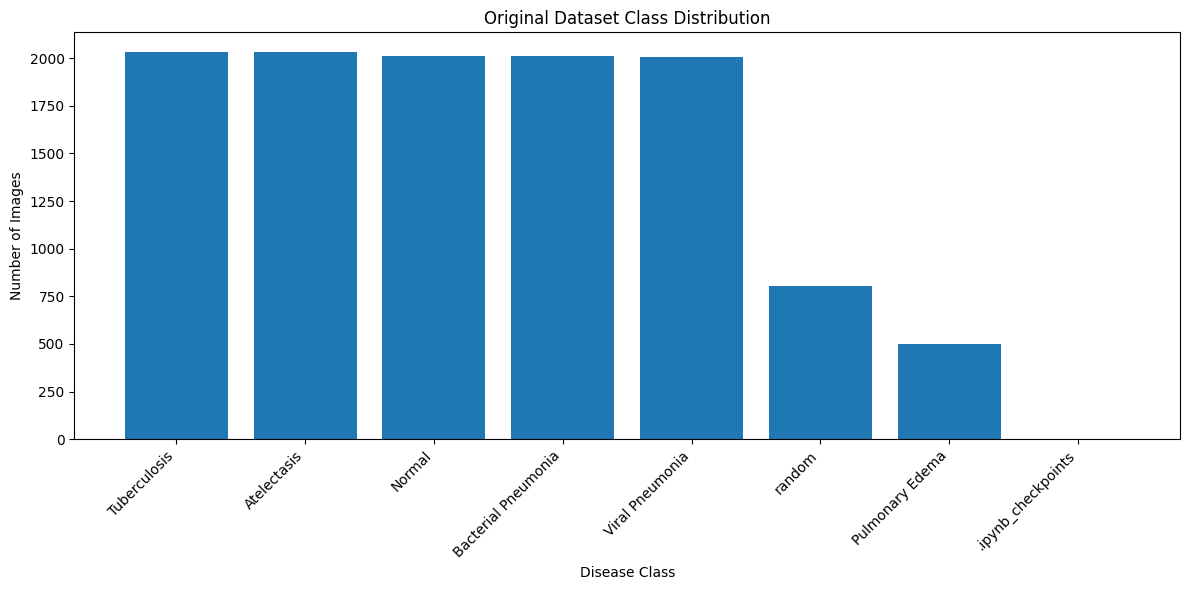

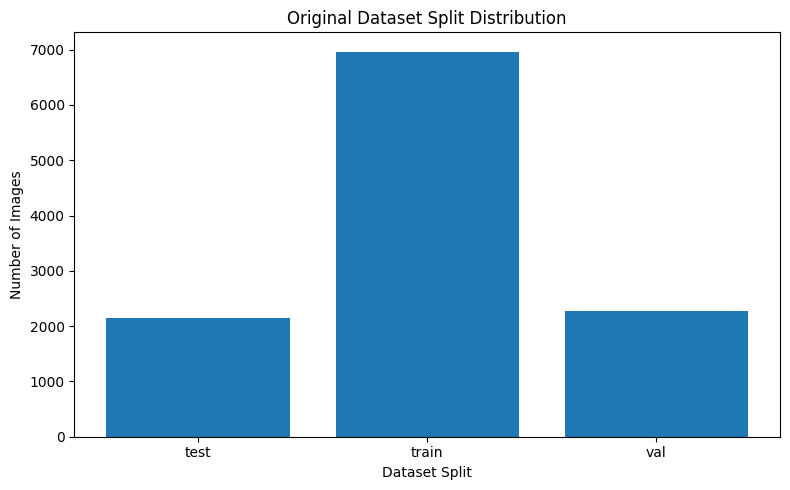


DATASET INSPECTION COMPLETE
Total images       : 11,397
Number of classes  : 8
Train images       : 6,965
Validation images  : 2,276
Test images        : 2,156
Imbalance ratio    : inf

✓ Original dataset inspection completed.
✓ Original dataset has NOT been modified.


In [4]:
# ============================================================
# 3. DATASET INSPECTION
# ============================================================

def list_images(folder):
    return [
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]


inspection_rows = []

for split in required_splits:

    split_dir = ORIGINAL_DATASET / split

    for class_dir in sorted(
        [p for p in split_dir.iterdir() if p.is_dir()]
    ):

        images = list_images(class_dir)

        inspection_rows.append({
            "split": split,
            "class": class_dir.name,
            "images": len(images),
            "path": str(class_dir)
        })


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

inspection_df = pd.DataFrame(inspection_rows)

print("=" * 70)
print("ORIGINAL DATASET INSPECTION")
print("=" * 70)

display(inspection_df)


# ------------------------------------------------------------
# TOTAL IMAGES
# ------------------------------------------------------------

total_images = inspection_df["images"].sum()

print("\nTotal Images:", f"{total_images:,}")


# ------------------------------------------------------------
# SPLIT DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGES BY SPLIT")
print("=" * 70)

split_summary = (
    inspection_df
    .groupby("split")["images"]
    .sum()
    .reset_index()
)

split_summary["percentage"] = (
    split_summary["images"] / total_images * 100
).round(2)

display(split_summary)


# ------------------------------------------------------------
# CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGES BY CLASS")
print("=" * 70)

class_summary = (
    inspection_df
    .groupby("class")["images"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

class_summary["percentage"] = (
    class_summary["images"] / total_images * 100
).round(2)

display(class_summary)


# ------------------------------------------------------------
# SPLIT × CLASS TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION ACROSS SPLITS")
print("=" * 70)

split_class_table = (
    inspection_df
    .pivot_table(
        index="class",
        columns="split",
        values="images",
        aggfunc="sum",
        fill_value=0
    )
)

display(split_class_table)


# ------------------------------------------------------------
# CHECK EMPTY CLASSES
# ------------------------------------------------------------

empty_classes = inspection_df[
    inspection_df["images"] == 0
]

if len(empty_classes) > 0:

    print("\nWARNING: Empty class folders detected:")

    display(empty_classes)

else:

    print("\n✓ No empty class folders detected.")


# ------------------------------------------------------------
# IDENTIFY CLASS IMBALANCE
# ------------------------------------------------------------

class_counts = class_summary["images"]

largest_class = int(class_counts.max())
smallest_class = int(class_counts.min())

imbalance_ratio = (
    largest_class / smallest_class
    if smallest_class > 0
    else float("inf")
)

print("\n" + "=" * 70)
print("CLASS IMBALANCE")
print("=" * 70)

print("Largest class :", f"{largest_class:,}")
print("Smallest class:", f"{smallest_class:,}")
print("Imbalance ratio:", round(imbalance_ratio, 2))


# ------------------------------------------------------------
# VISUALIZE CLASS DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    class_summary["class"],
    class_summary["images"]
)

plt.title("Original Dataset Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# VISUALIZE TRAIN / VAL / TEST
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    split_summary["split"],
    split_summary["images"]
)

plt.title("Original Dataset Split Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SAVE REPORTS
# ------------------------------------------------------------

inspection_df.to_csv(
    DIRS["reports"] /
    "01_original_dataset_distribution.csv",
    index=False
)

split_summary.to_csv(
    DIRS["reports"] /
    "01_split_summary.csv",
    index=False
)

class_summary.to_csv(
    DIRS["reports"] /
    "01_class_summary.csv",
    index=False
)

split_class_table.to_csv(
    DIRS["reports"] /
    "01_split_class_distribution.csv"
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET INSPECTION COMPLETE")
print("=" * 70)

print(f"Total images       : {total_images:,}")
print(f"Number of classes  : {len(class_summary)}")
print(f"Train images       : {int(split_summary.loc[split_summary['split']=='train', 'images'].sum()):,}")
print(f"Validation images  : {int(split_summary.loc[split_summary['split']=='val', 'images'].sum()):,}")
print(f"Test images        : {int(split_summary.loc[split_summary['split']=='test', 'images'].sum()):,}")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}")

print("\n✓ Original dataset inspection completed.")
print("✓ Original dataset has NOT been modified.")

## 4. Metadata support

If a metadata CSV/Excel/JSON is available later, it can be loaded here.

The notebook does not invent patient IDs or labels. If metadata contains `patient_id`, it can be used for leakage checks.

For the current folder-based dataset, the immediate class folder is used as the label.


In [5]:
# ============================================================
# 4. OPTIONAL METADATA
# ============================================================

# Put metadata in this location if you have it:
METADATA_PATH = None
# Example:
# METADATA_PATH = PROJECT_ROOT / "metadata.csv"

metadata_df = None

if METADATA_PATH is not None:
    METADATA_PATH = Path(METADATA_PATH)

    if not METADATA_PATH.exists():
        raise FileNotFoundError(f"Metadata not found: {METADATA_PATH}")

    suffix = METADATA_PATH.suffix.lower()

    if suffix == ".csv":
        metadata_df = pd.read_csv(METADATA_PATH)
    elif suffix in {".xlsx", ".xls"}:
        metadata_df = pd.read_excel(METADATA_PATH)
    elif suffix == ".json":
        metadata_df = pd.read_json(METADATA_PATH)
    else:
        raise ValueError("Supported metadata formats: CSV, XLSX/XLS, JSON")

    print("Metadata columns:")
    print(list(metadata_df.columns))

    display(metadata_df.head())

else:
    print("No metadata file configured.")
    print("Using folder names as class labels.")


No metadata file configured.
Using folder names as class labels.


## 5. Image acquisition

The original images are copied into the project's `data/acquired/` directory while preserving:

```text
train/
val/
test/
class/
```

The source dataset is never edited.


In [6]:
# ============================================================
# 5. IMAGE ACQUISITION
# ============================================================

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)

    return h.hexdigest()

acquisition_rows = []

for split in required_splits:
    split_dir = ORIGINAL_DATASET / split
    output_split = DIRS["acquired"] / split

    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        output_class = output_split / class_dir.name
        output_class.mkdir(parents=True, exist_ok=True)

        for src in tqdm(
            list_images(class_dir),
            desc=f"Acquiring {split}/{class_dir.name}"
        ):
            digest = sha256_file(src)

            # Keep original extension for this stage
            dst = output_class / src.name

            # Handle filename collisions safely
            if dst.exists():
                dst = output_class / f"{src.stem}_{digest[:10]}{src.suffix.lower()}"

            if not dst.exists():
                shutil.copy2(src, dst)

            acquisition_rows.append({
                "split": split,
                "label": class_dir.name,
                "original_path": str(src),
                "acquired_path": str(dst),
                "filename": src.name,
                "sha256": digest
            })

acquired_manifest = pd.DataFrame(acquisition_rows)

acquired_manifest.to_csv(
    DIRS["manifests"] / "02_acquired_manifest.csv",
    index=False
)

print(f"Acquired images: {len(acquired_manifest):,}")


Acquiring train/.ipynb_checkpoints: 0it [00:00, ?it/s]

Acquiring train/Atelectasis:   0%|          | 0/1218 [00:00<?, ?it/s]

Acquiring train/Bacterial Pneumonia:   0%|          | 0/1205 [00:00<?, ?it/s]

Acquiring train/Normal:   0%|          | 0/1207 [00:00<?, ?it/s]

Acquiring train/Pulmonary Edema:   0%|          | 0/350 [00:00<?, ?it/s]

...

Acquiring test/Pulmonary Edema:   0%|          | 0/50 [00:00<?, ?it/s]

Acquiring test/random:   0%|          | 0/81 [00:00<?, ?it/s]

Acquiring test/Tuberculosis:   0%|          | 0/408 [00:00<?, ?it/s]

Acquiring test/Viral Pneumonia:   0%|          | 0/403 [00:00<?, ?it/s]

Acquired images: 11,397


## 6. Cleaning

Cleaning checks:

- zero-byte files
- unreadable/corrupt images
- unsupported images
- exact duplicate files

The original data is never deleted. Rejected files are copied/referenced in the cleaning report.

Exact duplicates are detected using SHA-256.


In [15]:
# ============================================================
# 6. CLEANING
# ============================================================

import hashlib
from PIL import Image

print("=" * 70)
print("DATASET CLEANING")
print("=" * 70)

# ------------------------------------------------------------
# VALID DATASET STRUCTURE
# ------------------------------------------------------------

VALID_SPLITS = ["train", "val", "test"]

VALID_CLASSES = {
    "Atelectasis",
    "Bacterial Pneumonia",
    "Normal",
    "Pulmonary Edema",
    "Tuberculosis",
    "Viral Pneumonia"
}

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

CLEANED_ROOT = DATA_ROOT / "cleaned"
REJECTED_ROOT = DATA_ROOT / "reports"

CLEANED_ROOT.mkdir(parents=True, exist_ok=True)
REJECTED_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# SHA-256
# ------------------------------------------------------------

def calculate_sha256(path, chunk_size=1024 * 1024):

    sha256 = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


# ------------------------------------------------------------
# IMAGE VALIDATION
# ------------------------------------------------------------

def validate_image(path):

    # Zero-byte
    if path.stat().st_size == 0:
        return False, "zero_byte"

    # Extension
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        return False, "unsupported_extension"

    # PIL validation
    try:

        with Image.open(path) as img:

            img.verify()

        # Re-open after verify
        with Image.open(path) as img:

            img.load()

    except Exception:

        return False, "corrupt_or_unreadable"

    return True, "valid"


# ------------------------------------------------------------
# CLEANING
# ------------------------------------------------------------

cleaning_rows = []

seen_hashes = {}

valid_count = 0
rejected_count = 0
duplicate_count = 0


for split in VALID_SPLITS:

    split_dir = ORIGINAL_DATASET / split

    if not split_dir.exists():

        print(f"WARNING: Missing split: {split}")
        continue


    # --------------------------------------------------------
    # ONLY ACCEPT EXPECTED DISEASE DIRECTORIES
    # --------------------------------------------------------

    for item in split_dir.iterdir():

        # Ignore files directly inside train/val/test
        if not item.is_dir():

            cleaning_rows.append({
                "split": split,
                "class": "",
                "source": str(item),
                "status": "rejected",
                "reason": "file_outside_class_directory"
            })

            rejected_count += 1

            continue


        class_name = item.name


        # ----------------------------------------------------
        # UNKNOWN DIRECTORY
        # ----------------------------------------------------

        if class_name not in VALID_CLASSES:

            print(
                f"Rejected directory: "
                f"{split}/{class_name}"
            )

            for path in item.rglob("*"):

                if path.is_file():

                    cleaning_rows.append({
                        "split": split,
                        "class": class_name,
                        "source": str(path),
                        "status": "rejected",
                        "reason": "unknown_class_or_random_folder"
                    })

                    rejected_count += 1

            continue


        # ----------------------------------------------------
        # PROCESS VALID CLASS
        # ----------------------------------------------------

        output_class_dir = (
            CLEANED_ROOT /
            split /
            class_name
        )

        output_class_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        for path in item.rglob("*"):

            if not path.is_file():
                continue


            # Validate image
            valid, reason = validate_image(path)


            if not valid:

                cleaning_rows.append({
                    "split": split,
                    "class": class_name,
                    "source": str(path),
                    "status": "rejected",
                    "reason": reason
                })

                rejected_count += 1

                continue


            # ------------------------------------------------
            # DUPLICATE DETECTION
            # ------------------------------------------------

            file_hash = calculate_sha256(path)


            if file_hash in seen_hashes:

                cleaning_rows.append({
                    "split": split,
                    "class": class_name,
                    "source": str(path),
                    "status": "rejected",
                    "reason": "exact_duplicate",
                    "duplicate_of": seen_hashes[file_hash]
                })

                duplicate_count += 1
                rejected_count += 1

                continue


            seen_hashes[file_hash] = str(path)


            # ------------------------------------------------
            # COPY VALID IMAGE
            # ------------------------------------------------

            output_path = (
                output_class_dir /
                path.name
            )


            # Avoid filename collisions
            counter = 1

            while output_path.exists():

                output_path = (
                    output_class_dir /
                    f"{path.stem}_{counter}{path.suffix.lower()}"
                )

                counter += 1


            shutil.copy2(path, output_path)


            cleaning_rows.append({
                "split": split,
                "class": class_name,
                "source": str(path),
                "output": str(output_path),
                "status": "valid",
                "reason": "accepted",
                "sha256": file_hash
            })

            valid_count += 1


# ------------------------------------------------------------
# CLEANING REPORT
# ------------------------------------------------------------

cleaning_df = pd.DataFrame(cleaning_rows)

report_path = (
    REJECTED_ROOT /
    "02_cleaning_report.csv"
)

cleaning_df.to_csv(
    report_path,
    index=False
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLEANING COMPLETE")
print("=" * 70)

print(f"Valid images       : {valid_count:,}")
print(f"Rejected images    : {rejected_count:,}")
print(f"Exact duplicates   : {duplicate_count:,}")

print("\nRejection reasons:")

display(
    cleaning_df[
        cleaning_df["status"] == "rejected"
    ]
    ["reason"]
    .value_counts()
    .reset_index()
    .rename(
        columns={
            "reason": "Reason",
            "count": "Images"
        }
    )
)

print("\nCleaning report:")
print(report_path)

print("\n✓ Original dataset was NOT modified.")

DATASET CLEANING
Rejected directory: train/.ipynb_checkpoints
Rejected directory: train/random
Rejected directory: val/.ipynb_checkpoints
Rejected directory: val/random
Rejected directory: test/.ipynb_checkpoints
Rejected directory: test/random

CLEANING COMPLETE
Valid images       : 10,587
Rejected images    : 810
Exact duplicates   : 8

Rejection reasons:


,Reason,Images
0,unknown_class_or_random_folder,802
1,exact_duplicate,8



Cleaning report:
C:\Users\rushi\Desktop\Respira\data\reports\02_cleaning_report.csv

✓ Original dataset was NOT modified.


In [27]:
# ============================================================
# 7B. VALIDATE CLEAN MANIFEST
# ============================================================

VALID_CLASSES = [
    "Atelectasis",
    "Bacterial Pneumonia",
    "Normal",
    "Pulmonary Edema",
    "Tuberculosis",
    "Viral Pneumonia"
]

print("=" * 70)
print("VALIDATING CLEAN MANIFEST")
print("=" * 70)

# ------------------------------------------------------------
# Keep ONLY valid disease classes
# ------------------------------------------------------------

clean_manifest = clean_manifest[
    clean_manifest["label"].isin(VALID_CLASSES)
].copy()


# ------------------------------------------------------------
# Verify that invalid classes are gone
# ------------------------------------------------------------

remaining_classes = sorted(
    clean_manifest["label"]
    .dropna()
    .astype(str)
    .unique()
)

print("\nClasses remaining after cleaning:")

for cls in remaining_classes:
    print("  ✓", cls)


invalid_classes = set(remaining_classes) - set(VALID_CLASSES)

if invalid_classes:

    raise RuntimeError(
        f"Invalid classes still present: {invalid_classes}"
    )


if "random" in remaining_classes:

    raise RuntimeError(
        "CRITICAL: random is still present in clean_manifest."
    )


print("\n✓ RANDOM IS NOT PRESENT")
print("✓ Only valid disease classes remain")


# ------------------------------------------------------------
# Save corrected clean manifest
# ------------------------------------------------------------

clean_manifest.to_csv(
    DIRS["manifests"] / "05_clean_manifest_valid_classes.csv",
    index=False
)

print(
    "\nSaved:",
    DIRS["manifests"] / "05_clean_manifest_valid_classes.csv"
)

VALIDATING CLEAN MANIFEST

Classes remaining after cleaning:
  ✓ Atelectasis
  ✓ Bacterial Pneumonia
  ✓ Normal
  ✓ Pulmonary Edema
  ✓ Tuberculosis
  ✓ Viral Pneumonia

✓ RANDOM IS NOT PRESENT
✓ Only valid disease classes remain

Saved: C:\Users\rushi\Desktop\Respira\data\manifests\05_clean_manifest_valid_classes.csv


## 7. Leakage / duplicate audit

Before balancing or enhancement, exact duplicates across train/validation/test are reported.

If an exact duplicate occurs in multiple splits, it is a potential leakage problem.

**Do not automatically hide the issue.** The manifest preserves the evidence so it can be reported and corrected deliberately.


In [16]:
# ============================================================
# 7. DUPLICATE / LEAKAGE AUDIT
# ============================================================

hash_split_counts = (
    clean_manifest.groupby("sha256")["split"]
    .nunique()
    .reset_index(name="number_of_splits")
)

cross_split_hashes = hash_split_counts[
    hash_split_counts["number_of_splits"] > 1
]

print(
    f"Exact image hashes appearing in multiple splits: "
    f"{len(cross_split_hashes):,}"
)

if len(cross_split_hashes):
    leakage_rows = clean_manifest[
        clean_manifest["sha256"].isin(cross_split_hashes["sha256"])
    ].sort_values("sha256")

    display(leakage_rows[[
        "sha256", "split", "label", "acquired_path"
    ]].head(100))

    leakage_rows.to_csv(
        DIRS["reports"] / "02_cross_split_duplicate_audit.csv",
        index=False
    )
else:
    print("✓ No exact duplicate image found across train/val/test.")


Exact image hashes appearing in multiple splits: 0
✓ No exact duplicate image found across train/val/test.


## 8. Training-only balancing

The existing split is preserved.

Only the training data is balanced.

For the current folder-based single-label dataset, minority classes are oversampled to the largest training class. This is done by creating a balanced manifest and copied image references.

Validation and test remain untouched.


In [19]:
# ============================================================
# 8. BALANCING - TRAINING ONLY
# ============================================================
#
# IMPORTANT:
# - Original dataset is NOT modified
# - Validation and test are NOT balanced
# - Only approved disease classes are used
# - Minority classes are oversampled
# - No class is downsampled
# - Random/unknown classes are rejected
# - A reproducible balanced manifest is created
# ============================================================

from pathlib import Path
import shutil
import random
import pandas as pd
import numpy as np

print("=" * 70)
print("TRAINING-ONLY DATA BALANCING")
print("=" * 70)


# ============================================================
# 1. VALID DISEASE CLASSES
# ============================================================

VALID_CLASSES = [
    "Atelectasis",
    "Bacterial Pneumonia",
    "Normal",
    "Pulmonary Edema",
    "Tuberculosis",
    "Viral Pneumonia"
]

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# 2. CHECK CLEAN MANIFEST
# ============================================================

if "clean_manifest" not in globals():

    raise RuntimeError(
        "clean_manifest was not found.\n"
        "Please run the Cleaning section before Balancing."
    )


# ============================================================
# 3. DETECT LABEL COLUMN
# ============================================================

if "label" in clean_manifest.columns:

    LABEL_COLUMN = "label"

elif "class" in clean_manifest.columns:

    LABEL_COLUMN = "class"

else:

    raise ValueError(
        "Could not find a label/class column in clean_manifest."
    )


print(f"Using label column: {LABEL_COLUMN}")


# ============================================================
# 4. SAFETY CHECK - REMOVE UNKNOWN CLASSES
# ============================================================

all_classes = set(
    clean_manifest[LABEL_COLUMN]
    .dropna()
    .astype(str)
    .unique()
)

unexpected_classes = all_classes - set(VALID_CLASSES)


if unexpected_classes:

    print("\nWARNING: Unexpected classes detected:")
    print(sorted(unexpected_classes))

    print(
        "\nThese classes will NOT be included in the "
        "balanced training dataset."
    )


# ============================================================
# 5. SELECT TRAINING DATA ONLY
# ============================================================

train_df = clean_manifest[
    (clean_manifest["split"] == "train") &
    (clean_manifest[LABEL_COLUMN].isin(VALID_CLASSES))
].copy()


if train_df.empty:

    raise RuntimeError(
        "No valid training images were found."
    )


# ============================================================
# 6. VERIFY VALID CLASSES
# ============================================================

detected_classes = set(
    train_df[LABEL_COLUMN].astype(str).unique()
)

missing_classes = set(VALID_CLASSES) - detected_classes


if missing_classes:

    print("\nWARNING: Missing disease classes:")
    print(sorted(missing_classes))


# ============================================================
# 7. ORIGINAL TRAINING DISTRIBUTION
# ============================================================

original_distribution = (
    train_df[LABEL_COLUMN]
    .value_counts()
    .reindex(VALID_CLASSES, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)


print("\n" + "=" * 70)
print("ORIGINAL TRAINING DISTRIBUTION")
print("=" * 70)

display(original_distribution)


# ============================================================
# 8. TARGET SIZE
# ============================================================
#
# We use the largest valid training class as the target.
#
# Example:
#
# Atelectasis          1213
# Bacterial Pneumonia  1205
# Normal               1207
# Pulmonary Edema       350
# Tuberculosis         1220
# Viral Pneumonia      1204
#
# Target = 1220
#
# Therefore:
# minority classes are oversampled to 1220.
#
# No class is downsampled.
# ============================================================

target_count = int(
    original_distribution["count"].max()
)

print(
    f"\nTarget images per class: {target_count:,}"
)


# ============================================================
# 9. PREPARE BALANCED DIRECTORY
# ============================================================

BALANCED_ROOT = DIRS["balanced"]

if BALANCED_ROOT.exists():

    print(
        "\nRemoving previous balanced dataset..."
    )

    shutil.rmtree(BALANCED_ROOT)


BALANCED_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 10. FIND SOURCE PATH COLUMN
# ============================================================

possible_path_columns = [
    "source",
    "source_path",
    "path",
    "image_path",
    "original_path"
]

SOURCE_COLUMN = None

for column in possible_path_columns:

    if column in train_df.columns:

        SOURCE_COLUMN = column
        break


if SOURCE_COLUMN is None:

    raise ValueError(
        "Could not find the original image path column "
        "in clean_manifest."
    )


print(
    f"Using source path column: {SOURCE_COLUMN}"
)


# ============================================================
# 11. CREATE BALANCED DATASET
# ============================================================

balanced_rows = []


for class_name in VALID_CLASSES:

    class_df = train_df[
        train_df[LABEL_COLUMN] == class_name
    ].copy()


    current_count = len(class_df)


    if current_count == 0:

        print(
            f"\nSkipping {class_name}: "
            f"no training images found."
        )

        continue


    # --------------------------------------------------------
    # OVERSAMPLING
    # --------------------------------------------------------

    if current_count < target_count:

        additional_count = (
            target_count - current_count
        )

        additional_df = class_df.sample(
            n=additional_count,
            replace=True,
            random_state=SEED
        )

        balanced_class_df = pd.concat(
            [
                class_df,
                additional_df
            ],
            ignore_index=True
        )

        balancing_method = "oversampled"


    # --------------------------------------------------------
    # ALREADY BALANCED
    # --------------------------------------------------------

    elif current_count == target_count:

        balanced_class_df = class_df.copy()

        balancing_method = "unchanged"


    # --------------------------------------------------------
    # SAFETY: NEVER DOWNSAMPLE
    # --------------------------------------------------------

    else:

        balanced_class_df = class_df.copy()

        balancing_method = "kept_all"


    # --------------------------------------------------------
    # COPY IMAGES
    # --------------------------------------------------------

    class_output_dir = (
        BALANCED_ROOT /
        class_name
    )

    class_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    for index, row in balanced_class_df.reset_index(
        drop=True
    ).iterrows():

        source_path = Path(
            str(row[SOURCE_COLUMN])
        )


        if not source_path.exists():

            print(
                f"WARNING: Missing source image:\n"
                f"{source_path}"
            )

            continue


        # ----------------------------------------------------
        # CREATE UNIQUE OUTPUT NAME
        # ----------------------------------------------------

        original_stem = source_path.stem
        extension = source_path.suffix.lower()


        output_filename = (
            f"{class_name.replace(' ', '_')}_"
            f"{index:06d}_"
            f"{original_stem}"
            f"{extension}"
        )


        destination_path = (
            class_output_dir /
            output_filename
        )


        # ----------------------------------------------------
        # COPY IMAGE
        # ----------------------------------------------------

        shutil.copy2(
            source_path,
            destination_path
        )


        # ----------------------------------------------------
        # STORE MANIFEST RECORD
        # ----------------------------------------------------

        balanced_rows.append({

            "split": "train",

            "label": class_name,

            "source_path": str(
                source_path.resolve()
            ),

            "balanced_path": str(
                destination_path.resolve()
            ),

            "original_index": row.name,

            "balancing_method": balancing_method,

            "is_oversampled": (
                current_count < target_count
            ),

            "seed": SEED

        })


# ============================================================
# 12. CREATE BALANCED MANIFEST
# ============================================================

balanced_manifest = pd.DataFrame(
    balanced_rows
)


# ============================================================
# 13. VERIFY BALANCED DISTRIBUTION
# ============================================================

balanced_distribution = (
    balanced_manifest["label"]
    .value_counts()
    .reindex(VALID_CLASSES, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)


print("\n" + "=" * 70)
print("BALANCED TRAINING DISTRIBUTION")
print("=" * 70)

display(balanced_distribution)


# ============================================================
# 14. SAFETY CHECK - RANDOM MUST NOT EXIST
# ============================================================

unexpected_balanced_classes = set(
    balanced_manifest["label"].unique()
) - set(VALID_CLASSES)


if unexpected_balanced_classes:

    raise RuntimeError(
        "ERROR: Invalid classes entered the balanced dataset: "
        f"{sorted(unexpected_balanced_classes)}"
    )


if "random" in set(
    balanced_manifest["label"].astype(str).str.lower()
):

    raise RuntimeError(
        "CRITICAL ERROR: 'random' was found "
        "in the balanced dataset."
    )


print(
    "\n✓ No random/unknown classes included."
)


# ============================================================
# 15. VERIFY CLASS BALANCE
# ============================================================

non_zero_counts = balanced_distribution[
    balanced_distribution["count"] > 0
]["count"]


if len(non_zero_counts) > 0:

    if non_zero_counts.nunique() == 1:

        print(
            "✓ All available disease classes "
            "are perfectly balanced."
        )

    else:

        print(
            "WARNING: Class counts are not identical."
        )


# ============================================================
# 16. SAVE MANIFESTS AND REPORTS
# ============================================================

reports_dir = DIRS["reports"]

reports_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Original training distribution
original_distribution.to_csv(
    reports_dir /
    "03_original_training_distribution.csv",
    index=False
)


# Balanced training distribution
balanced_distribution.to_csv(
    reports_dir /
    "03_balanced_training_distribution.csv",
    index=False
)


# Complete balanced manifest
balanced_manifest.to_csv(
    reports_dir /
    "03_balanced_training_manifest.csv",
    index=False
)


# ============================================================
# 17. SUMMARY
# ============================================================

original_total = int(
    original_distribution["count"].sum()
)

balanced_total = int(
    balanced_distribution["count"].sum()
)


print("\n" + "=" * 70)
print("BALANCING COMPLETE")
print("=" * 70)

print(
    f"Original training images : {original_total:,}"
)

print(
    f"Balanced training images : {balanced_total:,}"
)

print(
    f"Target per class         : {target_count:,}"
)

print(
    f"Valid disease classes    : {len(VALID_CLASSES)}"
)

print(
    f"Expected balanced total  : "
    f"{target_count * len(VALID_CLASSES):,}"
)


print("\nClass distribution:")

display(balanced_distribution)


print("\nOutput directory:")
print(BALANCED_ROOT)


print("\nManifest:")
print(
    reports_dir /
    "03_balanced_training_manifest.csv"
)


print("\n✓ Original dataset was NOT modified.")
print("✓ Validation dataset was NOT modified.")
print("✓ Test dataset was NOT modified.")
print("✓ Only training data was balanced.")
print("✓ Unknown/random classes were excluded.")
print("✓ Oversampling is reproducible using SEED =", SEED)

TRAINING-ONLY DATA BALANCING
Using label column: label

['random']

These classes will NOT be included in the balanced training dataset.

ORIGINAL TRAINING DISTRIBUTION


,label,count
0,Atelectasis,1213
1,Bacterial Pneumonia,1205
2,Normal,1207
3,Pulmonary Edema,350
4,Tuberculosis,1220
5,Viral Pneumonia,1204



Target images per class: 1,220

Removing previous balanced dataset...
Using source path column: original_path

BALANCED TRAINING DISTRIBUTION


,label,count
0,Atelectasis,1220
1,Bacterial Pneumonia,1220
2,Normal,1220
3,Pulmonary Edema,1220
4,Tuberculosis,1220
5,Viral Pneumonia,1220



✓ No random/unknown classes included.
✓ All available disease classes are perfectly balanced.

BALANCING COMPLETE
Original training images : 6,399
Balanced training images : 7,320
Target per class         : 1,220
Valid disease classes    : 6
Expected balanced total  : 7,320

Class distribution:


,label,count
0,Atelectasis,1220
1,Bacterial Pneumonia,1220
2,Normal,1220
3,Pulmonary Edema,1220
4,Tuberculosis,1220
5,Viral Pneumonia,1220



Output directory:
C:\Users\rushi\Desktop\Respira\data\balanced

Manifest:
C:\Users\rushi\Desktop\Respira\data\reports\03_balanced_training_manifest.csv

✓ Original dataset was NOT modified.
✓ Validation dataset was NOT modified.
✓ Test dataset was NOT modified.
✓ Only training data was balanced.
✓ Unknown/random classes were excluded.
✓ Oversampling is reproducible using SEED = 42


## 9. Create balanced training copies

This stage physically creates the balanced training set.

Validation and test are **not** copied into the balanced directory.


In [20]:
# ============================================================
# 9. CREATE BALANCED TRAIN DATA
# ============================================================

balanced_paths = []

for _, row in tqdm(
    balanced_train.iterrows(),
    total=len(balanced_train),
    desc="Creating balanced training set"
):
    src = Path(row["acquired_path"])
    label = str(row["label"])

    dst_dir = DIRS["balanced"] / "train" / label
    dst_dir.mkdir(parents=True, exist_ok=True)

    dst = dst_dir / (
        f"{int(row['balanced_id']):08d}_{src.stem}.png"
    )

    # Convert/copy as PNG to normalize the next stage
    with Image.open(src) as img:
        img.convert("L").save(dst)

    balanced_paths.append(str(dst))

balanced_train["balanced_path"] = balanced_paths

balanced_train.to_csv(
    DIRS["manifests"] / "05_balanced_train_paths.csv",
    index=False
)

print("Balanced train created at:")
print(DIRS["balanced"] / "train")


Creating balanced training set:   0%|          | 0/8540 [00:00<?, ?it/s]

Balanced train created at:
C:\Users\rushi\Desktop\Respira\data\balanced\train


## 10. CLAHE enhancement

CLAHE is applied to grayscale chest X-rays.

Parameters:

- clip limit: `2.0`
- tile grid: `8 × 8`

The same parameters are used for train, validation and test.


In [21]:
# ============================================================
# 10. CLAHE
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_GRID_SIZE
)

def clahe_image(input_path, output_path):
    image = cv2.imread(
        str(input_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(f"Cannot read image: {input_path}")

    enhanced = clahe.apply(image)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    cv2.imwrite(str(output_path), enhanced)

# Build the processing table:
# train = balanced train
# val/test = untouched cleaned splits

train_process = balanced_train.copy()
train_process["processing_split"] = "train"
train_process["processing_source"] = train_process["balanced_path"]

val_process = val_df.copy()
val_process["processing_split"] = "val"
val_process["processing_source"] = val_process["acquired_path"]

test_process = test_df.copy()
test_process["processing_split"] = "test"
test_process["processing_source"] = test_process["acquired_path"]

processing_manifest = pd.concat(
    [train_process, val_process, test_process],
    ignore_index=True,
    sort=False
)

clahe_paths = []

for idx, row in tqdm(
    processing_manifest.iterrows(),
    total=len(processing_manifest),
    desc="Applying CLAHE"
):
    src = Path(row["processing_source"])

    unique_id = hashlib.sha1(
        f"{row['processing_split']}|{idx}|{src}".encode()
    ).hexdigest()[:16]

    dst = (
        DIRS["clahe"]
        / row["processing_split"]
        / str(row["label"])
        / f"{unique_id}.png"
    )

    clahe_image(src, dst)
    clahe_paths.append(str(dst))

processing_manifest["clahe_path"] = clahe_paths

processing_manifest.to_csv(
    DIRS["manifests"] / "06_clahe_manifest.csv",
    index=False
)

print("CLAHE stage complete.")


Applying CLAHE:   0%|          | 0/12966 [00:00<?, ?it/s]

CLAHE stage complete.


## 11. Lung masking

A reproducible OpenCV-based lung-region mask is generated from the CLAHE image.

### Important research note

This is an **automatic heuristic lung mask**, not a medical-grade segmentation model. It is useful as a preprocessing baseline, but the final report should describe it accurately.

If you later provide a dedicated lung segmentation model/mask, this function can be replaced without changing the rest of the pipeline.


In [22]:
# ============================================================
# 11. LUNG MASKING
# ============================================================

def create_lung_mask(gray):
    """
    Conservative automatic lung-region heuristic.

    Steps:
      1. Normalize image
      2. Gaussian smoothing
      3. Otsu threshold
      4. Morphological cleanup
      5. Keep large central components
      6. Fallback to central elliptical region if needed

    This is NOT a clinical segmentation algorithm.
    """

    img = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    blur = cv2.GaussianBlur(
        img,
        (5, 5),
        0
    )

    _, threshold = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (9, 9)
    )

    mask = cv2.morphologyEx(
        threshold,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    h, w = mask.shape

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    candidates = []

    for component_id in range(1, num_labels):
        x, y, cw, ch, area = stats[component_id]
        cx, cy = centroids[component_id]

        # Reject tiny components
        if area < 0.03 * h * w:
            continue

        # Prefer central chest components
        if (
            0.10 * w <= cx <= 0.90 * w
            and
            0.10 * h <= cy <= 0.92 * h
        ):
            candidates.append(
                (area, component_id)
            )

    candidates.sort(reverse=True)

    lung_mask = np.zeros_like(mask)

    # Keep the two strongest candidate regions
    for _, component_id in candidates[:2]:
        lung_mask[labels == component_id] = 255

    # Fallback
    if np.count_nonzero(lung_mask) < 0.05 * h * w:
        yy, xx = np.ogrid[:h, :w]

        cx = w / 2
        cy = h * 0.52
        rx = w * 0.38
        ry = h * 0.40

        ellipse = (
            ((xx - cx) ** 2 / rx ** 2)
            +
            ((yy - cy) ** 2 / ry ** 2)
            <= 1
        )

        lung_mask[ellipse] = 255

    # Soften the mask boundary
    lung_mask = cv2.GaussianBlur(
        lung_mask,
        (7, 7),
        0
    )

    return lung_mask


def apply_lung_mask(gray):
    mask = create_lung_mask(gray)

    mask_float = (
        mask.astype(np.float32) / 255.0
    )

    masked = (
        gray.astype(np.float32)
        * mask_float
    )

    return (
        np.clip(masked, 0, 255)
        .astype(np.uint8),
        mask
    )


## 12. Final 224×224 dataset

Processing order is strictly:

```text
CLAHE → LUNG MASK → RESIZE 224×224
```

The final image is stored as a **3-channel RGB PNG**, making it directly usable by standard ImageNet-pretrained architectures:

- DenseNet121
- ViT
- EfficientNet-B0
- proposed DenseNet121 + ViT architecture


In [23]:
# ============================================================
# 12. MASK + 224x224 FINAL DATASET
# ============================================================

def create_final_image(input_path, output_path):
    gray = cv2.imread(
        str(input_path),
        cv2.IMREAD_GRAYSCALE
    )

    if gray is None:
        raise ValueError(
            f"Cannot read CLAHE image: {input_path}"
        )

    masked, mask = apply_lung_mask(gray)

    resized = cv2.resize(
        masked,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    # Convert to 3 channels for pretrained CNN/ViT models
    if OUTPUT_CHANNELS == 3:
        final = cv2.cvtColor(
            resized,
            cv2.COLOR_GRAY2RGB
        )
    else:
        final = resized

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    cv2.imwrite(
        str(output_path),
        cv2.cvtColor(final, cv2.COLOR_RGB2BGR)
    )

    return mask, final


processed_paths = []
mask_paths = []

for idx, row in tqdm(
    processing_manifest.iterrows(),
    total=len(processing_manifest),
    desc="Masking + resizing to 224x224"
):
    clahe_path = Path(row["clahe_path"])

    unique_id = hashlib.sha1(
        f"{row['processing_split']}|{idx}|{clahe_path}".encode()
    ).hexdigest()[:16]

    label = str(row["label"])
    split = str(row["processing_split"])

    final_path = (
        DIRS["processed"]
        / split
        / label
        / f"{unique_id}.png"
    )

    mask_path = (
        DIRS["masked"]
        / split
        / label
        / f"{unique_id}_mask.png"
    )

    mask, final = create_final_image(
        clahe_path,
        final_path
    )

    cv2.imwrite(
        str(mask_path),
        mask
    )

    processed_paths.append(str(final_path))
    mask_paths.append(str(mask_path))

processing_manifest["processed_path"] = processed_paths
processing_manifest["mask_path"] = mask_paths

processing_manifest.to_csv(
    DIRS["manifests"] / "07_final_processed_manifest.csv",
    index=False
)

print("Final dataset created:")
print(DIRS["processed"])


Masking + resizing to 224x224:   0%|          | 0/12966 [00:00<?, ?it/s]

Final dataset created:
C:\Users\rushi\Desktop\Respira\data\processed


## 13. Verify final dataset

This checks that:

- train/val/test exist
- every final image is readable
- images are exactly `224 × 224`
- channels are correct
- validation/test counts were not changed by balancing


In [24]:
# ============================================================
# 13. FINAL DATASET VERIFICATION
# ============================================================

verification_rows = []

for _, row in tqdm(
    processing_manifest.iterrows(),
    total=len(processing_manifest),
    desc="Verifying final images"
):
    path = Path(row["processed_path"])

    try:
        img = cv2.imread(
            str(path),
            cv2.IMREAD_UNCHANGED
        )

        valid = (
            img is not None
            and img.shape[0] == IMAGE_SIZE[0]
            and img.shape[1] == IMAGE_SIZE[1]
        )

        channels = (
            1 if img is not None and len(img.shape) == 2
            else (img.shape[2] if img is not None else 0)
        )

        verification_rows.append({
            "path": str(path),
            "split": row["processing_split"],
            "label": row["label"],
            "height": img.shape[0] if img is not None else 0,
            "width": img.shape[1] if img is not None else 0,
            "channels": channels,
            "valid": valid
        })

    except Exception as e:
        verification_rows.append({
            "path": str(path),
            "split": row["processing_split"],
            "label": row["label"],
            "height": 0,
            "width": 0,
            "channels": 0,
            "valid": False
        })

verification_df = pd.DataFrame(
    verification_rows
)

display(
    verification_df["valid"]
    .value_counts()
    .rename_axis("valid")
    .reset_index(name="count")
)

bad = verification_df[
    ~verification_df["valid"]
]

if len(bad):
    print("WARNING: invalid final images found:")
    display(bad.head(20))
else:
    print("✓ All final images are valid 224×224 images.")


Verifying final images:   0%|          | 0/12966 [00:00<?, ?it/s]

,valid,count
0,True,12966


✓ All final images are valid 224×224 images.


## 14. Final class distribution

This is the distribution that should be used in the experiment report.

Note that training is balanced while validation and test retain their original distributions.


In [25]:
# ============================================================
# 14. FINAL DISTRIBUTION
# ============================================================

final_distribution = (
    processing_manifest
    .groupby(
        ["processing_split", "label"]
    )
    .size()
    .reset_index(name="count")
)

display(final_distribution)

final_distribution.to_csv(
    DIRS["reports"] / "03_final_distribution.csv",
    index=False
)

split_summary = (
    processing_manifest["processing_split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="images")
)

display(split_summary)

split_summary.to_csv(
    DIRS["reports"] / "04_final_split_summary.csv",
    index=False
)


,processing_split,label,count
0,test,Atelectasis,404
1,test,Bacterial Pneumonia,403
2,test,Normal,404
3,test,Pulmonary Edema,50
4,test,Tuberculosis,408
5,test,Viral Pneumonia,403
6,test,random,79
7,train,Atelectasis,1220
8,train,Bacterial Pneumonia,1220
9,train,Normal,1220


,split,images
0,train,8540
1,val,2275
2,test,2151


## 15. Visual quality check

Inspect representative images before training.

The panel shows:

**Original → CLAHE → Lung Mask → Final 224×224**


TypeError: Image data of dtype object cannot be converted to float

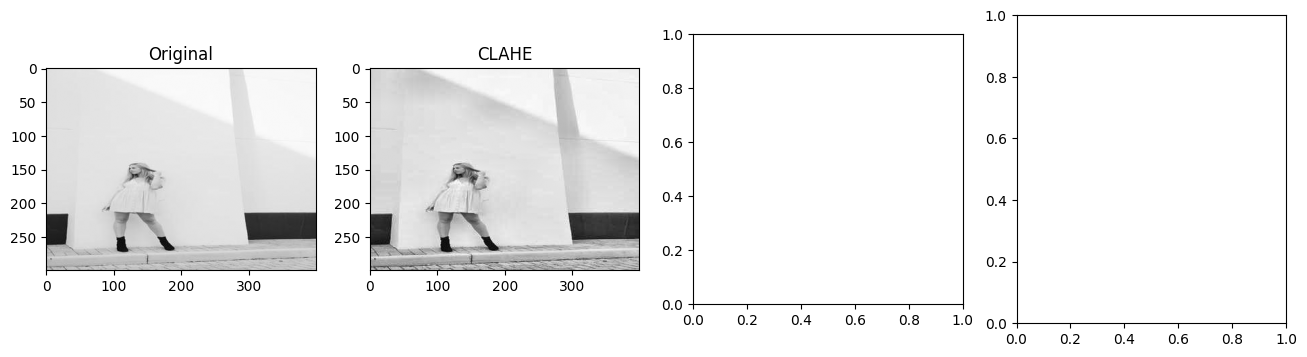

In [26]:
# ============================================================
# 15. VISUAL QUALITY CHECK
# ============================================================

def show_pipeline_example(row_index=0):
    row = processing_manifest.iloc[row_index]

    original = cv2.imread(
        str(row["processing_source"]),
        cv2.IMREAD_GRAYSCALE
    )

    clahe_img = cv2.imread(
        str(row["clahe_path"]),
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        str(row["mask_path"]),
        cv2.IMREAD_GRAYSCALE
    )

    final = cv2.imread(
        str(row["processed_path"]),
        cv2.IMREAD_COLOR
    )

    final = cv2.cvtColor(
        final,
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(
        1, 4,
        figsize=(16, 4)
    )

    axes[0].imshow(
        original,
        cmap="gray"
    )
    axes[0].set_title("Original")

    axes[1].imshow(
        clahe_img,
        cmap="gray"
    )
    axes[1].set_title("CLAHE")

    axes[2].imshow(
        mask,
        cmap="gray"
    )
    axes[2].set_title("Lung Mask")

    axes[3].imshow(final)
    axes[3].set_title("Final 224×224")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("Split :", row["processing_split"])
    print("Label :", row["label"])
    print("Source:", row["processing_source"])


show_pipeline_example(0)


## 16. Save preprocessing configuration

This configuration file records exactly how the dataset was produced.

That is important because every experiment must use the same preprocessing protocol for a fair comparison.


In [ ]:
# ============================================================
# 16. SAVE CONFIGURATION
# ============================================================

config = {
    "project_root": str(PROJECT_ROOT),
    "original_dataset": str(ORIGINAL_DATASET),

    "source_policy": {
        "single_original_source_only": True,
        "original_dataset_modified": False,
        "existing_split_preserved": True,
        "old_processed_datasets_merged": False
    },

    "seed": SEED,

    "splits": {
        "train": "existing original train split",
        "validation": "existing original val split",
        "test": "existing original test split"
    },

    "balancing": {
        "enabled": True,
        "applied_to": "train_only",
        "method": BALANCE_METHOD
    },

    "clahe": {
        "enabled": True,
        "clip_limit": CLAHE_CLIP_LIMIT,
        "tile_grid_size": list(CLAHE_TILE_GRID_SIZE)
    },

    "lung_mask": {
        "enabled": True,
        "method": "opencv_conservative_heuristic",
        "clinical_grade": False
    },

    "resize": {
        "width": IMAGE_SIZE[0],
        "height": IMAGE_SIZE[1]
    },

    "output": {
        "channels": OUTPUT_CHANNELS,
        "format": "PNG"
    },

    "final_dataset": str(DIRS["processed"])
}

with open(
    DIRS["reports"] / "preprocessing_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config,
        f,
        indent=2
    )

print(json.dumps(config, indent=2))


# Final output structure

After running the notebook:

```text
Respira/
│
├── env/
│
├── Lung_Disease_Dataset/              # ORIGINAL — untouched
│   ├── train/
│   ├── val/
│   └── test/
│
├── preprocessing/
│   └── preprocessing_pipeline.ipynb   # this notebook
│
└── data/
    ├── acquired/
    │   ├── train/
    │   ├── val/
    │   └── test/
    │
    ├── cleaned/
    │   └── rejected/
    │
    ├── balanced/
    │   └── train/
    │
    ├── clahe/
    │   ├── train/
    │   ├── val/
    │   └── test/
    │
    ├── masked/
    │   ├── train/
    │   ├── val/
    │   └── test/
    │
    ├── processed/
    │   ├── train/
    │   ├── val/
    │   └── test/
    │
    ├── manifests/
    │
    └── reports/
```

## Model experiments

All models should read **only** from:

```text
Respira/data/processed/
```

Therefore:

```text
data/processed/
       │
       ├── DenseNet121
       ├── ViT
       ├── EfficientNet-B0
       └── Proposed DenseNet121 + ViT
```

All experiments use the same final preprocessing, making their accuracy comparison meaningful.
